# 2. MusSkl donor clustering

Part of the **[Fig. 6 chapter](fig6.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}npc.tsv'`  ·  _metadata_
- `f'{indir}L2/{ct}/5kCG_embed.h5ad'`  ·  _embedding h5ad_
- `f'{indir}L2/{ct}/100k3C_embed.h5ad'`  ·  _embedding h5ad_
- `'Mus-Skl/5kCG100k3C_embed.h5ad'`  ·  _embedding h5ad_
- `f'{indir}embedding/SkGcn/cell_table.tsv'`  ·  _table_
- `f'{indir}embedding/SkGcn/{chrom}.npz'`  ·  _other_
- `f'Mus-Skl/{mode}_{xx}_embed.h5ad'`  ·  _embedding h5ad_
- `'Mus-Skl/5kCG100k3C_embed_new.h5ad'`  ·  _embedding h5ad_
- `f'{ENTEX_ROOT}/allclist.tsv'`  ·  _sc/pseudobulk mC (allc)_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [1]:
import os
from glob import glob
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import cooler
import anndata
import scanpy as sc
import scanpy.external as sce
from ALLCools.clustering import *
from ALLCools.plot import *
from ALLCools.mcds import MCDS
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

# mpl.use('agg')
mpl.style.use("default")
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = "Helvetica"

import warnings
warnings.filterwarnings("ignore")


In [2]:
def dump_embedding(adata, name, n_dim=2):
    # put manifold coordinates into adata.obs
    for i in range(n_dim):
        adata.obs[f'{name}_{i}'] = adata.obsm[f'X_{name}'][:, i]
    return adata


In [3]:
indir = f'{ENTEX_ROOT}/clustering/merged/'
outdir = f'{ENTEX_ROOT}/analysis/pairwise_prediction/'


In [4]:
ct = 'Mus-Skl'


In [5]:
npc = pd.read_csv(f'{indir}npc.tsv', sep='\t', header=None, index_col=0, names=['npc_cg', 'npc_3c'])

In [6]:
adata_mc = anndata.read_h5ad(f'{indir}L2/{ct}/5kCG_embed.h5ad')
adata_3c = anndata.read_h5ad(f'{indir}L2/{ct}/100k3C_embed.h5ad')
adata_3c = adata_3c[adata_mc.obs.index].copy()


In [5]:
adata = anndata.read_h5ad('Mus-Skl/5kCG100k3C_embed.h5ad')
adata

AnnData object with n_obs × n_vars = 3973 × 0
    obs: 'FinalmCReads', 'mCHFrac', 'mCGFrac', 'CisLongContact', 'Cis/Trans', 'Donor', 'Tissue', 'celltype', 'ClusterTissue', 'tsne_0', 'tsne_1', 'leiden_cons', 'leiden_cv', 'leiden_init', 'leiden_init_mc', 'leiden_init_3c', 'leiden_group_mc', 'leiden_group_3c', 'group_mc_3c'
    obsm: '5kCG100k3C_u7pc10', '5kCG100k3C_u7pc10_tsne', 'X_tsne'

In [8]:
adata.obs['Donor'].value_counts()

Donor
PT-1K2DA    2152
PT-1LVAN    1821
Name: count, dtype: int64

## Using uncorrected embedding


In [6]:
def rename_cluster(xx):
    yy = xx.replace('-','/').replace('mc','').replace('3c','')
    yy = yy.replace('0', 'Stem').replace('1', 'Fast').replace('2', 'Slow')
    return yy

leg = np.sort(adata.obs['group_mc_3c'].unique())
k1, k2 = 0, 0
color_palette = {}
for xx in leg:
    x1, x2 = xx.split('-')
    if x1[1:]==x2[1:]:
        color_palette[rename_cluster(xx)] = sns.color_palette('tab20')[k1*2+1]
        k1 += 1
    else:
        color_palette[rename_cluster(xx)] = sns.color_palette('tab20')[k2*2]
        k2 += 1


In [9]:
adata_list = []
for obsm_key, raw_key, adata_tmp in zip(['X_lsi', 'X_pca'], ['5kCG_lsi', '100k3C_pca'], [adata_mc, adata_3c]):
    for xx in adata.obs['Donor'].unique():
        tmp = adata_tmp[adata_tmp.obs['Donor']==xx].copy()
        # npc = significant_pc_test(tmp, p_cutoff=0.05, obsm=obsm_key, update=False)
        # tmp.obsm[obsm_key] = normalize(tmp.obsm[raw_key][:, :10], axis=1)
        tsne(tmp, obsm=obsm_key, metric='euclidean', exaggeration=-1, perplexity=50, n_jobs=-1)
        sc.pp.neighbors(tmp, n_neighbors=25, use_rep=obsm_key)
        sc.tl.leiden(tmp, resolution=0.5, random_state=0, flavor='igraph')
        adata_list.append(tmp.copy())
        print(obsm_key, xx)
        

X_lsi PT-1K2DA
X_lsi PT-1LVAN
X_pca PT-1K2DA
X_pca PT-1LVAN


In [20]:
# clustering name
clustering_name = 'L1'

# ConsensusClustering
# Important factores
n_neighbors = 25
leiden_resolution = 0.1
# this parameter is the final target that limit the total number of clusters
# Higher accuracy means more conservative clustering results and less number of clusters
target_accuracy = 0.9
min_cluster_size = 50

# Other ConsensusClustering parameters
metric = 'euclidean'
consensus_rate = 0.8
leiden_repeats = 500
random_state = 0
train_frac = 0.5
train_max_n = 500
max_iter = 50
n_jobs = 32

# Dendrogram via Multiscale Bootstrap Resampling
nboot = 10000
method_dist = 'correlation'
method_hclust = 'average'

plot_type = 'static'
cc = ConsensusClustering(model=None,
                         n_neighbors=n_neighbors,
                         metric=metric,
                         min_cluster_size=min_cluster_size,
                         leiden_repeats=leiden_repeats,
                         leiden_resolution=leiden_resolution,
                         consensus_rate=consensus_rate,
                         random_state=random_state,
                         train_frac=train_frac,
                         train_max_n=train_max_n,
                         max_iter=max_iter,
                         n_jobs=n_jobs,
                         target_accuracy=target_accuracy)


In [23]:
for tmp in adata_list:
    sc.tl.leiden(tmp, resolution=0.1, random_state=0, flavor='igraph')


In [27]:
for i,obsm_key in enumerate(['X_lsi', 'X_pca']):
    for j,xx in enumerate(adata.obs['Donor'].unique()):
        tmp = adata_list[i*2+j]
        cc.fit_predict(tmp.obsm[obsm_key])
        tmp.obs['consensus_leiden_init'] = cc.label.copy()


Computing nearest neighbor graph
Computing multiple clustering with different random seeds
Repeating leiden clustering 500 times
Found 2 - 3 clusters, mean 2.7, std 0.47
Summarizing multiple clustering results
2142 cells assigned to 3 raw clusters
10 cells are multi-leiden outliers

=== Start supervise model training and cluster merging ===

=== iteration 1 ===
3 non-outlier labels
Balanced accuracy on the training set: 0.993
Balanced accuracy on the hold-out set: 0.970
Stop iteration because current accuracy 0.970 > target accuracy 0.900.

=== Assign final labels ===
Assigned all the multi-leiden clustering outliers into clusters using the prediction model from final clustering version.
Final ten-fold CV Accuracy on all the cells: 0.975
Computing nearest neighbor graph
Computing multiple clustering with different random seeds
Repeating leiden clustering 500 times
Found 3 - 3 clusters, mean 3.0, std 0.00
Summarizing multiple clustering results
1821 cells assigned to 2 raw clusters
0 ce

In [29]:
for i in range(2):
    for j in range(2):
        tmp = adata_list[i*2+j]
        tmp.obs['consensus_leiden_other'] = adata_list[(1-i)*2+j].obs['consensus_leiden_init'].values
        

In [34]:
adata_list[0].obs[['consensus_leiden_init','consensus_leiden_other']].value_counts().unstack()

consensus_leiden_other,c0,c1,c2
consensus_leiden_init,,,
c0,1060,141,1
c1,47,544,1
c2,151,158,49


In [37]:
adata_list[1].obs[['consensus_leiden_init','consensus_leiden_other']].value_counts().unstack().fillna(0).astype(int)

consensus_leiden_other,c0,c1,c2
consensus_leiden_init,,,
c0,800,23,0
c1,35,767,1
c2,70,40,85


## Using donor separated embedding

In [ ]:
var_dim = 'chrom5k'
chrom_to_remove = ['chrX', 'chrY', 'chrM', 'chrL']
mcds_path_list = glob(f'{ENTEX_ROOT}/mcds/*mcds')
mcds = MCDS.open(mcds_path_list, var_dim=var_dim)
mcds = mcds.remove_chromosome(exclude_chromosome=chrom_to_remove, var_dim=var_dim)
mcds

42659 chrom5k features in ['chrX', 'chrY', 'chrM', 'chrL'] removed.


<xarray.MCDS> Size: 108GB
Dimensions:                    (cell: 93550, chrom5k: 575010)
Coordinates:
  * cell                       (cell) <U34 13MB 'PBMC_11714_Plate1-1-A1-A1' ....
  * chrom5k                    (chrom5k) <U11 25MB 'chr1_0' ... 'chr9_27678'
    chrom5k_chrom              (chrom5k) <U5 12MB dask.array<chunksize=(38605,), meta=np.ndarray>
    chrom5k_end                (chrom5k) int64 5MB dask.array<chunksize=(77209,), meta=np.ndarray>
    chrom5k_start              (chrom5k) int64 5MB dask.array<chunksize=(77209,), meta=np.ndarray>
Data variables:
    chrom5k_da_CGN-hypo-score  (cell, chrom5k) float16 108GB dask.array<chunksize=(7, 77209), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  chrom5k

In [ ]:
mcds = mcds.sel(cell=adata.obs.index)
mcds

<xarray.MCDS> Size: 5GB
Dimensions:                    (cell: 3973, chrom5k: 575010)
Coordinates:
  * cell                       (cell) <U34 540kB 'SkGcn_C1MKW_Plate1-1-O3-A1'...
  * chrom5k                    (chrom5k) <U11 25MB 'chr1_0' ... 'chr9_27678'
    chrom5k_chrom              (chrom5k) <U5 12MB dask.array<chunksize=(38605,), meta=np.ndarray>
    chrom5k_end                (chrom5k) int64 5MB dask.array<chunksize=(77209,), meta=np.ndarray>
    chrom5k_start              (chrom5k) int64 5MB dask.array<chunksize=(77209,), meta=np.ndarray>
Data variables:
    chrom5k_da_CGN-hypo-score  (cell, chrom5k) float16 5GB dask.array<chunksize=(4, 77209), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  chrom5k

In [ ]:
mcad = mcds.get_score_adata(mc_type='CGN', quant_type='hypo')
binarize_matrix(mcad, cutoff=0.95)


Loading chunk 0-3973/3973


In [ ]:
black_list_path = f'{REF_ROOT}/blacklist/hg38-blacklist.v2.bed.gz'
filter_regions(mcad, n_cell=5)
remove_black_list_region(mcad, black_list_path=black_list_path)


489595 regions remained.
10035 regions removed due to overlapping (bedtools intersect -f 0.2) with black list regions.


In [ ]:
mcad.write_h5ad(f'{indir}L2/{ct}/5kCG.h5ad')

In [ ]:
model = LSI(scale_factor=10000,
            n_components=50,
            algorithm='arpack',
            random_state=0)


In [ ]:
raw_key = '5kCG_lsi'
obsm_key = 'X_lsi'
adata_mc_list = []
for xx in adata.obs['Donor'].unique():
    tmp = mcad[adata.obs['Donor']==xx].copy()
    model.fit_transform(tmp, obsm_name='5kCG_lsi')
    npc = significant_pc_test(tmp, p_cutoff=0.1, obsm=raw_key, update=False)
    tmp.obsm[obsm_key] = normalize(tmp.obsm[raw_key][:, :npc], axis=1)
    tsne(tmp, obsm=obsm_key, metric='euclidean', exaggeration=-1, perplexity=50, n_jobs=-1)
    adata_mc_list.append(tmp.copy())
    print(obsm_key, xx)
    

5 components passed P cutoff of 0.05.
X_lsi PT-1K2DA
11 components passed P cutoff of 0.05.
X_lsi PT-1LVAN


In [ ]:
chrom_size_path = f'{REF_ROOT}/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


In [ ]:
indir = f'{ENTEX_ROOT}/'

In [ ]:

dim = 50
cell_list = pd.read_csv(f'{indir}embedding/SkGcn/cell_table.tsv', index_col=0, header=None, sep='\t')
cell_list['index'] = np.arange(cell_list.shape[0])
matrix = [[], []]
for chrom in chrom_sizes.index:
    data = np.load(f'{indir}embedding/SkGcn/{chrom}.npz')['arr_0']
    for i,xx in enumerate(adata.obs['Donor'].unique()):
        selc = adata.obs.index[adata.obs['Donor']==xx]
        tmp = data[cell_list.loc[selc, 'index'].values]
        dim = min(dim, tmp.shape[0] - 1, tmp.shape[1] - 1)
        model = TruncatedSVD(n_components=dim, algorithm='arpack')
        tmp_reduce = model.fit_transform(tmp)
        matrix[i].append(tmp_reduce / model.singular_values_)
    print(chrom)


chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
chr21
chr22


In [ ]:
raw_key = '100k3C_pca'
obsm_key = 'X_pca'
model = TruncatedSVD(n_components=dim, algorithm='arpack')
adata_3c_list = []
for i,xx in enumerate(adata.obs['Donor'].unique()):
    selc = adata.obs.index[adata.obs['Donor']==xx]
    tmp = anndata.AnnData(X=np.concatenate(matrix[i], axis=1), obs=adata.obs.loc[selc].copy())
    tmp.obsm[raw_key] = model.fit_transform(tmp.X)
    tmp.uns['100k3C_eigen'] = model.singular_values_.copy()
    npc = significant_pc_test(tmp, p_cutoff=0.1, obsm=raw_key, update=False)
    tmp.obsm[obsm_key] = normalize(tmp.obsm[raw_key][:, :npc], axis=1)
    tsne(tmp, obsm=obsm_key, metric='euclidean', exaggeration=-1, perplexity=50, n_jobs=-1)
    adata_3c_list.append(tmp.copy())
    print(obsm_key, xx)


7 components passed P cutoff of 0.05.
X_pca PT-1K2DA
6 components passed P cutoff of 0.05.
X_pca PT-1LVAN


In [ ]:
for i,xx in enumerate(adata.obs['Donor'].unique()):
    tmp = adata_3c_list[i].copy()
    tmp = anndata.AnnData(obs=tmp.obs, obsm=tmp.obsm)
    tmp.write_h5ad(f'Mus-Skl/100k3C_{xx}_embed.h5ad')
    tmp = adata_mc_list[i].copy()
    tmp = anndata.AnnData(obs=tmp.obs, obsm=tmp.obsm)
    tmp.write_h5ad(f'Mus-Skl/5kCG_{xx}_embed.h5ad')


In [9]:
adata_list = []

for mode in ['5kCG', '100k3C']:
    for xx in adata.obs['Donor'].unique():
        tmp = anndata.read_h5ad(f'Mus-Skl/{mode}_{xx}_embed.h5ad')
        adata_list.append(tmp.copy())
        print(mode, xx)
        

5kCG PT-1K2DA
5kCG PT-1LVAN
100k3C PT-1K2DA
100k3C PT-1LVAN


In [36]:
# clustering name
clustering_name = 'L1'

# ConsensusClustering
# Important factores
n_neighbors = 25
leiden_resolution = 0.1
# this parameter is the final target that limit the total number of clusters
# Higher accuracy means more conservative clustering results and less number of clusters
target_accuracy = 0.9
min_cluster_size = 50

# Other ConsensusClustering parameters
metric = 'euclidean'
consensus_rate = 0.8
leiden_repeats = 500
random_state = 0
train_frac = 0.5
train_max_n = 500
max_iter = 50
n_jobs = 32

# Dendrogram via Multiscale Bootstrap Resampling
nboot = 10000
method_dist = 'correlation'
method_hclust = 'average'

plot_type = 'static'
cc = ConsensusClustering(model=None,
                         n_neighbors=n_neighbors,
                         metric=metric,
                         min_cluster_size=min_cluster_size,
                         leiden_repeats=leiden_repeats,
                         leiden_resolution=leiden_resolution,
                         consensus_rate=consensus_rate,
                         random_state=random_state,
                         train_frac=train_frac,
                         train_max_n=train_max_n,
                         max_iter=max_iter,
                         n_jobs=n_jobs,
                         target_accuracy=target_accuracy)


In [37]:
# for i,obsm_key in enumerate(['X_lsi', 'X_pca']]):
i = 1
obsm_key = 'X_pca'
for j,xx in enumerate(adata.obs['Donor'].unique()):
    tmp = adata_list[i*2+j]
    cc.fit_predict(tmp.obsm[obsm_key])
    tmp.obs['consensus_leiden_init'] = cc.label.copy()


Computing nearest neighbor graph
Computing multiple clustering with different random seeds
Repeating leiden clustering 500 times


Found 2 - 3 clusters, mean 3.0, std 0.06
Summarizing multiple clustering results
2152 cells assigned to 2 raw clusters
0 cells are multi-leiden outliers

=== Start supervise model training and cluster merging ===

=== iteration 1 ===
3 non-outlier labels
Balanced accuracy on the training set: 0.964
Balanced accuracy on the hold-out set: 0.952
Stop iteration because current accuracy 0.952 > target accuracy 0.900.

=== Assign final labels ===
Assigned all the multi-leiden clustering outliers into clusters using the prediction model from final clustering version.
Final ten-fold CV Accuracy on all the cells: 0.969
Computing nearest neighbor graph
Computing multiple clustering with different random seeds
Repeating leiden clustering 500 times
Found 3 - 3 clusters, mean 3.0, std 0.00
Summarizing multiple clustering results
1821 cells assigned to 2 raw clusters
0 cells are multi-leiden outliers

=== Start supervise model training and cluster merging ===

=== iteration 1 ===
3 non-outlier label

In [39]:
for i in range(2):
    for j in range(2):
        tmp = adata_list[i*2+j]
        tmp.obs['consensus_leiden_other'] = adata_list[(1-i)*2+j].obs['consensus_leiden_init'].values
        

In [44]:
adata_list[0].obs[['consensus_leiden_init','consensus_leiden_other']].value_counts().unstack().fillna(0).astype(int)

consensus_leiden_other,c0,c1,c2
consensus_leiden_init,,,
c0,1053,152,3
c1,52,497,0
c2,143,202,50


In [42]:
adata_list[1].obs[['consensus_leiden_init','consensus_leiden_other']].value_counts().unstack().fillna(0).astype(int)

consensus_leiden_other,c0,c1,c2
consensus_leiden_init,,,
c0,774,36,1
c1,21,773,1
c2,89,41,85


In [10]:
adata.obs['leiden_group_mc'] = 'm' + pd.concat([adata_list[0].obs['consensus_leiden_init'].astype(str).map({'c2':'c0','c0':'c2','c1':'c1'}), adata_list[1].obs['consensus_leiden_init'].astype(str).map({'c2':'c0','c0':'c1','c1':'c2'})])
adata.obs['leiden_group_3c'] = '3' + pd.concat([adata_list[2].obs['consensus_leiden_init'].astype(str).map({'c2':'c0','c0':'c2','c1':'c1'}), adata_list[3].obs['consensus_leiden_init'].astype(str).map({'c2':'c0','c0':'c1','c1':'c2'})])


In [11]:
count = adata.obs[['leiden_group_mc', 'leiden_group_3c']].value_counts().unstack()
count

leiden_group_3c,3c0,3c1,3c2
leiden_group_mc,,,
mc0,135,291,184
mc1,1,1271,88
mc2,4,173,1826


In [ ]:
# Fig 6D — donor-corrected mC-vs-3C confusion matrix for Mus-Skl.
# `count` above is the crosstab of the donor-corrected group labels (matches published
# 135/291/184 / 1/1271/88 / 4/173/1826). Draw it as a table.
count6d = count.reindex(index=sorted(count.index), columns=sorted(count.columns))
fig, ax = plt.subplots(figsize=(4, 4), dpi=300)
ax.table(cellText=count6d.values, cellLoc='center', loc='center', rowLoc='right',
         rowLabels=count6d.index, colLabels=count6d.columns)
ax.axis('off')
fig.tight_layout()
fig.savefig('Mus-Skl/mc3c_confusion_donor.pdf', transparent=True)  # Fig 6D


In [12]:
adata.obs['group_mc_3c_old'] = adata.obs['group_mc_3c'].copy()
adata.obs['group_mc_3c_old'] = adata.obs['group_mc_3c_old'].map(rename_cluster)

In [13]:
adata.obs['group_mc_3c'] = adata.obs['leiden_group_mc'].astype(str) + '-' + adata.obs['leiden_group_3c'].astype(str)
adata.obs['group_mc_3c'] = adata.obs['group_mc_3c'].map(rename_cluster)

In [9]:
data = adata.obs.loc[~adata.obs['group_mc_3c'].isin(['Fast/Stem', 'Slow/Stem'])]
data['group_mc_3c'] = data['group_mc_3c'].astype(str)


In [10]:
adata

AnnData object with n_obs × n_vars = 3973 × 0
    obs: 'FinalmCReads', 'mCHFrac', 'mCGFrac', 'CisLongContact', 'Cis/Trans', 'Donor', 'Tissue', 'celltype', 'ClusterTissue', 'tsne_0', 'tsne_1', 'leiden_cons', 'leiden_cv', 'leiden_init', 'leiden_init_mc', 'leiden_init_3c', 'leiden_group_mc', 'leiden_group_3c', 'group_mc_3c', 'group_mc_3c_old'
    obsm: '5kCG100k3C_u7pc10', '5kCG100k3C_u7pc10_tsne', 'X_tsne'

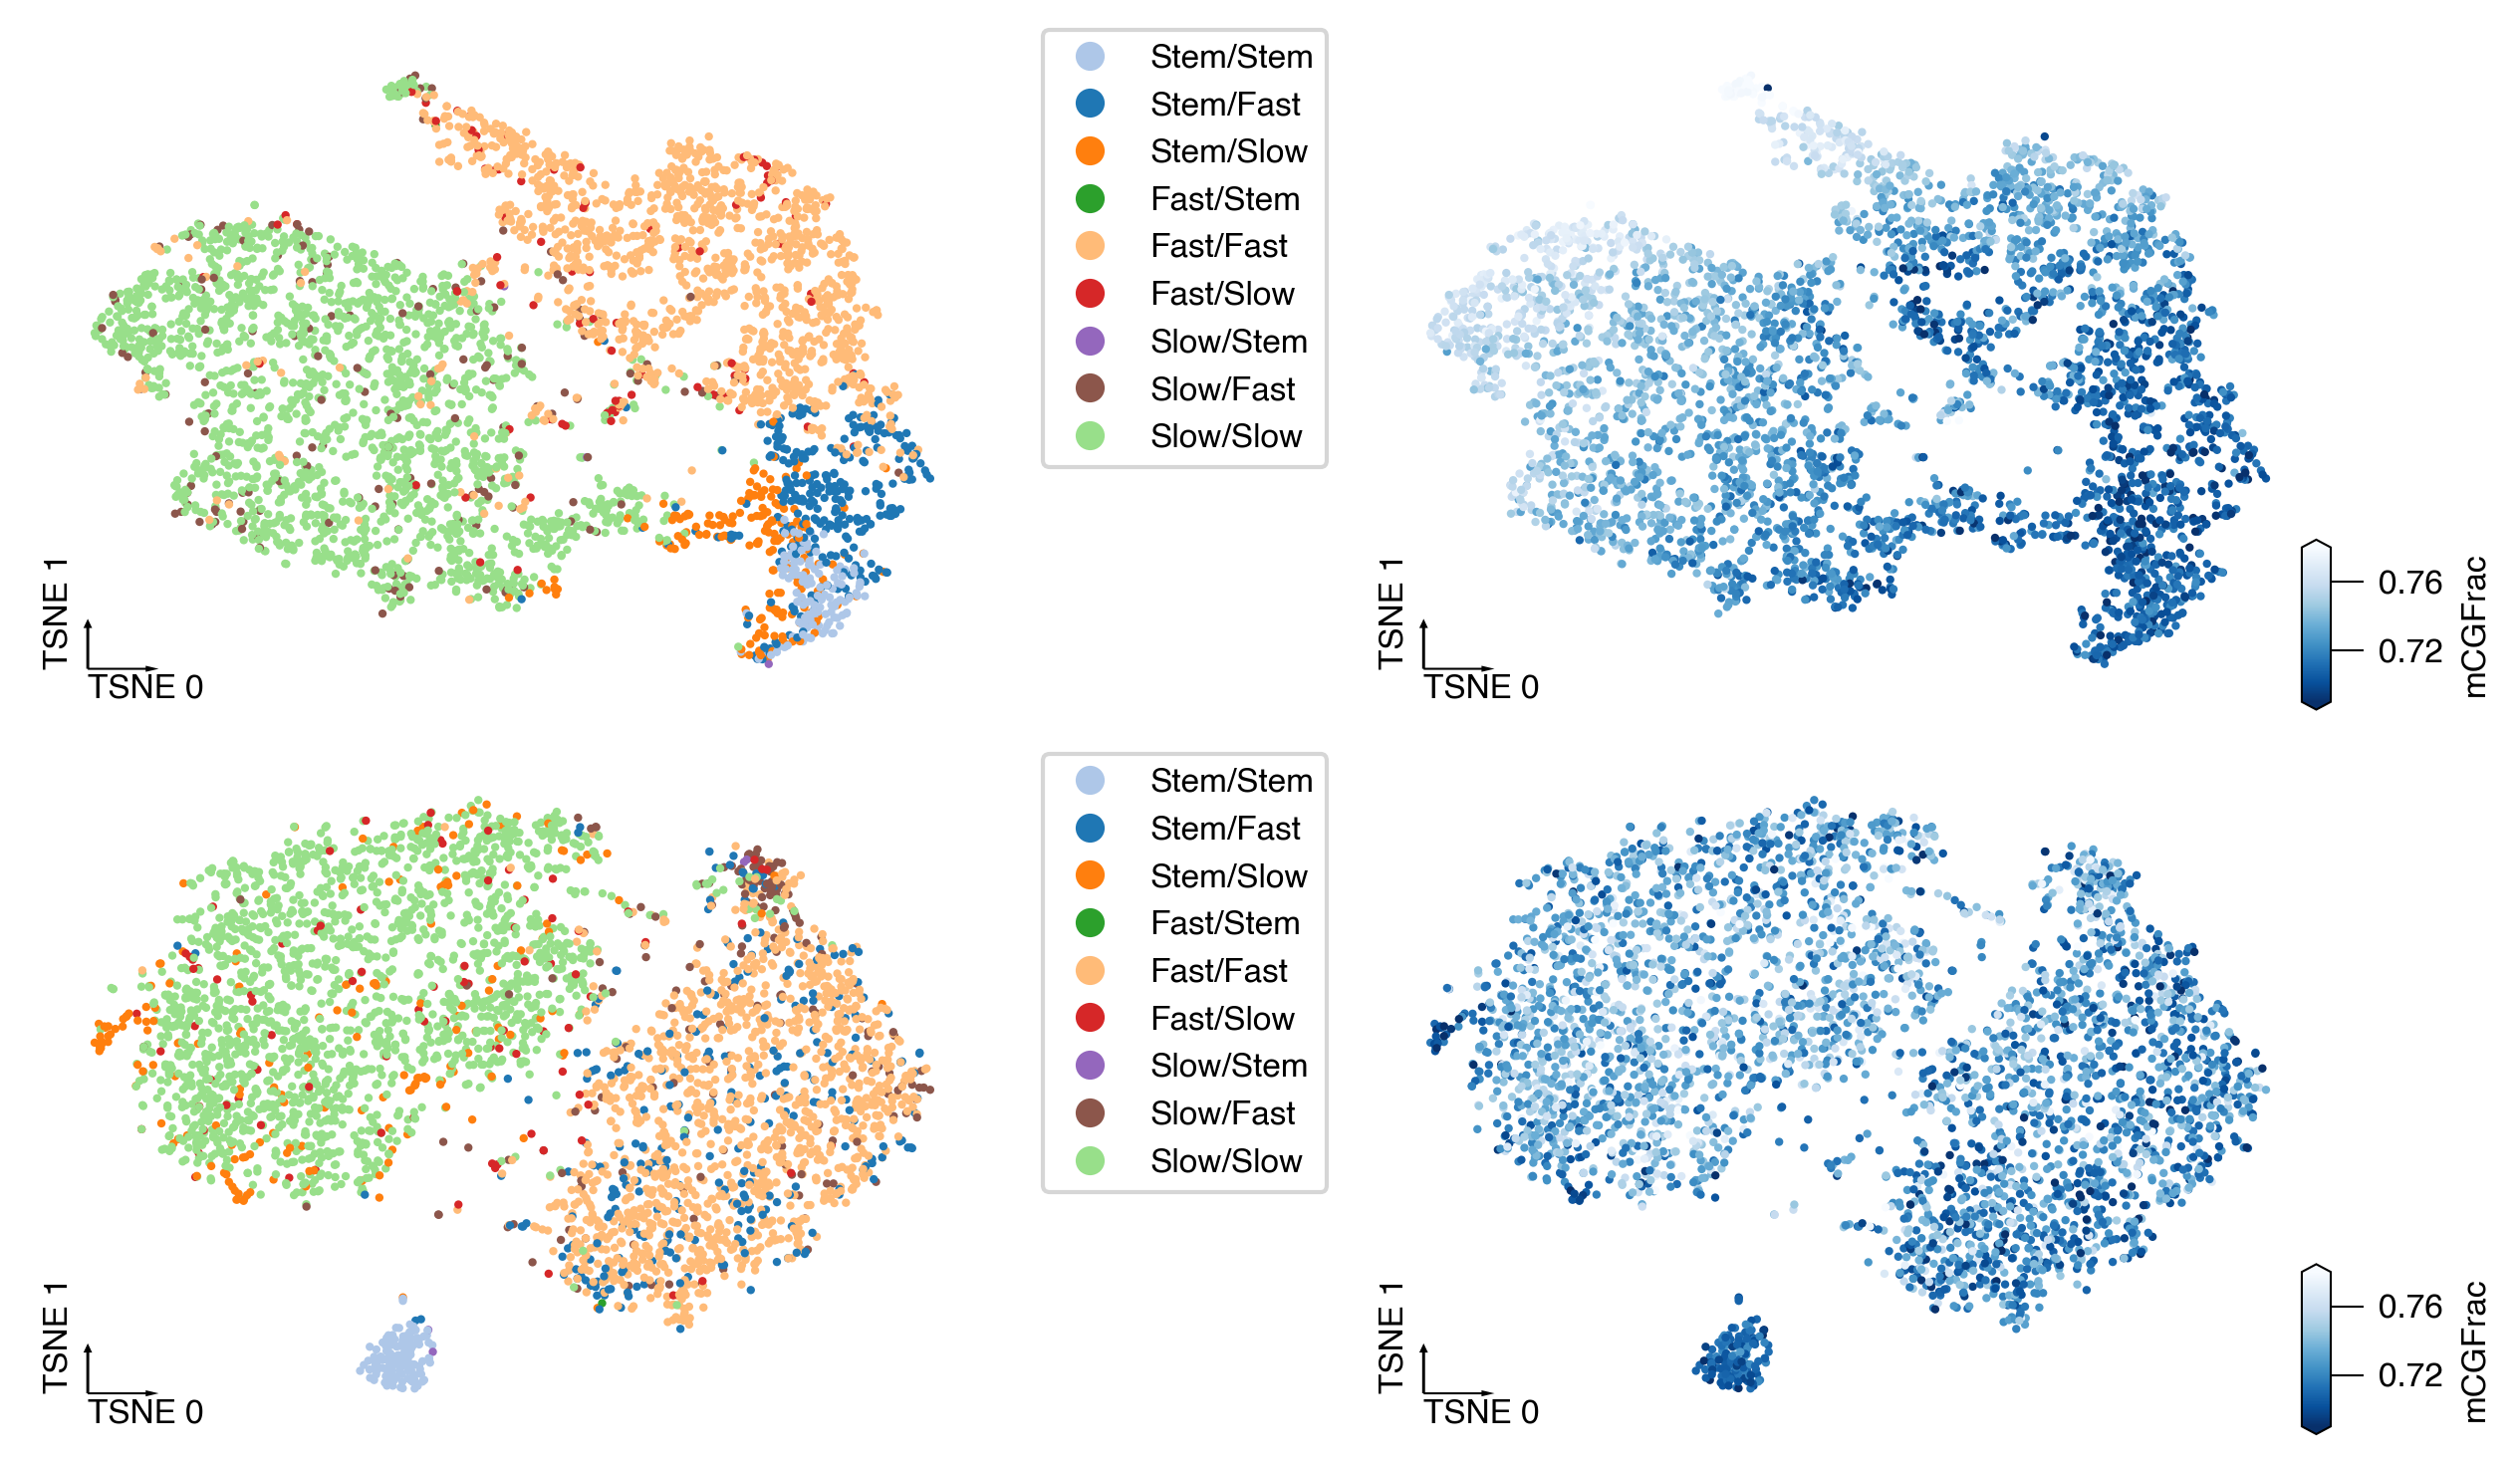

In [17]:
ds = 4
coord_base = 'tsne'
fig, axes = plt.subplots(2, 2, figsize=(8,5), dpi=300)
for i,adata_tmp in enumerate([adata_mc, adata_3c]):
    tmp = adata_tmp.obs.copy()
    tmp['group_mc_3c'] = adata.obs['group_mc_3c'].astype(str)
    tmp['group_mc_3c'] = tmp['group_mc_3c'].map(rename_cluster)
    ax = axes[i,0]
    _ = categorical_scatter(data=tmp,
                            ax=ax,
                            coord_base=coord_base,
                            hue='group_mc_3c',
                            # text_anno='group_mc_3c', 
                            s=ds,
                            labelsize=8,
                            max_points=None,
                            palette=color_palette,
                            scatter_kws={'rasterized':True},
                            # legend_kws={'ncol':1}, 
                            show_legend=True
                            )
    ax = axes[i,1]
    _ = continuous_scatter(data=tmp,
                           ax=ax,
                           coord_base=coord_base,
                           hue=adata.obs['mCGFrac'],
                           s=ds,
                           cmap='Blues_r',
                           labelsize=8,
                           max_points=None,
                           scatter_kws={'rasterized':True},
                           hue_norm=[0.69, 0.78],
                           )

fig.tight_layout()
fig.savefig('Mus-Skl/mC_3C_embed_group_mCG_new.pdf', transparent=True)


In [71]:
for i,mode in enumerate(['5kCG', '100k3C']):
    for j,xx in enumerate(adata.obs['Donor'].unique()):
        tmp = adata_list[i*2+j].copy()
        tmp.write_h5ad(f'Mus-Skl/{mode}_{xx}_embed.h5ad')

In [7]:
adata_list = []
for i,mode in enumerate(['5kCG', '100k3C']):
    for j,xx in enumerate(adata.obs['Donor'].unique()):
        tmp = anndata.read_h5ad(f'Mus-Skl/{mode}_{xx}_embed.h5ad')
        adata_list.append(tmp)


In [8]:
adata.obs['leiden_group_mc'] = 'm' + pd.concat([adata_list[0].obs['consensus_leiden_init'].astype(str).map({'c2':'c0','c0':'c2','c1':'c1'}), adata_list[1].obs['consensus_leiden_init'].astype(str).map({'c2':'c0','c0':'c1','c1':'c2'})])
adata.obs['leiden_group_3c'] = '3' + pd.concat([adata_list[2].obs['consensus_leiden_init'].astype(str).map({'c2':'c0','c0':'c2','c1':'c1'}), adata_list[3].obs['consensus_leiden_init'].astype(str).map({'c2':'c0','c0':'c1','c1':'c2'})])


In [9]:
adata.obs['group_mc_3c_old'] = adata.obs['group_mc_3c'].copy()
adata.obs['group_mc_3c_old'] = adata.obs['group_mc_3c_old'].map(rename_cluster)

In [10]:
adata.obs['group_mc_3c'] = adata.obs['leiden_group_mc'].astype(str) + '-' + adata.obs['leiden_group_3c'].astype(str)
adata.obs['group_mc_3c'] = adata.obs['group_mc_3c'].map(rename_cluster)

In [11]:
pd.DataFrame([adata.obs['group_mc_3c_old'].str.split('/').str[0], adata.obs['group_mc_3c'].str.split('/').str[0]], index=['old', 'new']).T.value_counts()

old   new 
Slow  Slow    1957
Fast  Fast    1234
Stem  Stem     496
Slow  Fast     125
Fast  Stem      90
      Slow      40
Slow  Stem      24
Stem  Slow       6
      Fast       1
Name: count, dtype: int64

In [ ]:
ct1, ct2 = 'Fast', 'Stem'
# ct1, ct2 = 'Slow', 'Fast'
selc = adata.obs.index[(adata.obs['group_mc_3c_old'].str.split('/').str[0]==ct1) & (adata.obs['group_mc_3c'].str.split('/').str[0]==ct2)]
np.savetxt(f'Mus-Skl/allc/allclist_mc{ct1}_mc{ct2}.txt', f'{ENTEX_ROOT}/allc/' + selc + '.CGN-Both.allc.tsv.gz', fmt='%s')


In [36]:
print((1957+1234+496)/3973, (125+40)/(125+90+40+24+6+1))

0.9280140951422099 0.5769230769230769


In [12]:
pd.DataFrame([adata.obs['group_mc_3c_old'].str.split('/').str[1], adata.obs['group_mc_3c'].str.split('/').str[1]], index=['old', 'new']).T.value_counts()

old   new 
Slow  Slow    2043
Fast  Fast    1683
Stem  Stem     136
Fast  Slow      54
Slow  Fast      50
Fast  Stem       4
Stem  Fast       2
      Slow       1
Name: count, dtype: int64

In [37]:
print((2043+1683+136)/3973, (54+50)/(54+50+7))

0.9720614145482004 0.9369369369369369


In [13]:
(adata.obs['group_mc_3c_old']==adata.obs['group_mc_3c']).sum()/3973

0.9048577900830607

In [15]:
adata.write_h5ad('Mus-Skl/5kCG100k3C_embed_new.h5ad')

In [6]:
adata = anndata.read_h5ad('Mus-Skl/5kCG100k3C_embed_new.h5ad')
adata

AnnData object with n_obs × n_vars = 3973 × 0
    obs: 'FinalmCReads', 'mCHFrac', 'mCGFrac', 'CisLongContact', 'Cis/Trans', 'Donor', 'Tissue', 'celltype', 'ClusterTissue', 'tsne_0', 'tsne_1', 'leiden_cons', 'leiden_cv', 'leiden_init', 'leiden_init_mc', 'leiden_init_3c', 'leiden_group_mc', 'leiden_group_3c', 'group_mc_3c', 'group_mc_3c_old'
    obsm: '5kCG100k3C_u7pc10', '5kCG100k3C_u7pc10_tsne', 'X_tsne'

In [17]:
adata.obs[['group_mc_3c', 'group_mc_3c_old']]

,group_mc_3c,group_mc_3c_old
cell,,
SkGcn_C1MKW_Plate1-1-O3-A1,Slow/Slow,Slow/Slow
SkGcn_C1MKW_Plate1-1-O3-A14,Slow/Fast,Slow/Fast
SkGcn_C1MKW_Plate1-1-O3-B13,Slow/Slow,Slow/Slow
SkGcn_C1MKW_Plate1-1-O3-B14,Slow/Slow,Slow/Slow
SkGcn_C1MKW_Plate1-1-O3-B2,Fast/Fast,Fast/Fast
...,...,...
SkGcn_C1PWV_Plate8-6-O14-O12,Fast/Fast,Fast/Fast
SkGcn_C1PWV_Plate8-6-O14-O24,Slow/Slow,Slow/Slow
SkGcn_C1PWV_Plate8-6-O14-P12,Stem/Fast,Stem/Fast


In [45]:
adata.obs[['group_mc_3c_old', 'group_mc_3c']].value_counts().sort_index()

group_mc_3c_old  group_mc_3c
Stem/Stem        Slow/Stem         1
                 Stem/Fast         1
                 Stem/Slow         1
                 Stem/Stem       134
Stem/Fast        Fast/Fast         1
                 Slow/Fast         1
                 Slow/Slow         1
                 Stem/Fast       192
                 Stem/Slow         4
                 Stem/Stem         1
Stem/Slow        Slow/Slow         3
                 Stem/Fast         8
                 Stem/Slow       155
Fast/Stem        Stem/Fast         1
Fast/Fast        Fast/Fast      1154
                 Fast/Slow        11
                 Slow/Fast        15
                 Stem/Fast        79
                 Stem/Slow         1
Fast/Slow        Fast/Fast        16
                 Fast/Slow        53
                 Slow/Fast         4
                 Slow/Slow        21
                 Stem/Fast         4
                 Stem/Slow         5
Slow/Stem        Slow/Stem         1
Slow/Fast

In [48]:
adata.obs[['group_mc_3c', 'group_mc_3c_old']].value_counts().sort_index()

group_mc_3c  group_mc_3c_old
Fast/Fast    Stem/Fast             1
             Fast/Fast          1154
             Fast/Slow            16
             Slow/Fast            98
             Slow/Slow             2
Fast/Slow    Fast/Fast            11
             Fast/Slow            53
             Slow/Fast             5
             Slow/Slow            19
Fast/Stem    Slow/Fast             1
Slow/Fast    Stem/Fast             1
             Fast/Fast            15
             Fast/Slow             4
             Slow/Fast           137
             Slow/Slow            16
Slow/Slow    Stem/Fast             1
             Stem/Slow             3
             Fast/Slow            21
             Slow/Fast            32
             Slow/Slow          1769
Slow/Stem    Stem/Stem             1
             Slow/Stem             1
             Slow/Fast             2
Stem/Fast    Stem/Stem             1
             Stem/Fast           192
             Stem/Slow             8
         

In [68]:
allc_table = pd.read_csv(f'{ENTEX_ROOT}/allclist.tsv', sep='\t', index_col=0, header=None)
allc_table

,1
0,
M1C_3C_001_Plate1-1-F3-A1,/gale/netapp/entex/ENTEx/Pool_BVBW_M1C/output_...
M1C_3C_001_Plate1-1-F3-A2,/gale/netapp/entex/ENTEx/Pool_BVBW_M1C/output_...
M1C_3C_001_Plate1-1-F3-B13,/gale/netapp/entex/ENTEx/Pool_BVBW_M1C/output_...
M1C_3C_001_Plate1-1-F3-B14,/gale/netapp/entex/ENTEx/Pool_BVBW_M1C/output_...
M1C_3C_001_Plate1-1-F3-B1,/gale/netapp/entex/ENTEx/Pool_BVBW_M1C/output_...
...,...
Sk_IOBHT_AR_Plate7-6-I24-O24,/gale/netapp/entex/ENTEx/Pool_EFEG_AG_LG_P_PI_...
Sk_IOBHT_AR_Plate7-6-I24-P11,/gale/netapp/entex/ENTEx/Pool_EFEG_AG_LG_P_PI_...
Sk_IOBHT_AR_Plate7-6-I24-P12,/gale/netapp/entex/ENTEx/Pool_EFEG_AG_LG_P_PI_...


In [69]:
adata.obs['allcpath'] = '/gale/netapp/entex/ENTEx/allc_CGN/' + adata.obs.index + '.CGN-Both.allc.tsv.gz'
# adata.obs['allcpath'] = allc_table.loc[adata.obs.index, 1]
adata.obs['coolpath'] = 'gs://ecker-zhoujt-analysis/ENTEx/tissue/' + adata.obs['Tissue'].astype(str) + '/impute/10K/' + adata.obs.index + '.cool'


In [72]:
tmp = adata.obs[['leiden_group_mc', 'leiden_group_3c', 'allcpath', 'coolpath']].copy()
tmp['group_mc_3c'] = tmp['leiden_group_mc'].astype(str) + '-' + tmp['leiden_group_3c'].astype(str)
count = tmp['group_mc_3c'].value_counts()
tmp = tmp.loc[tmp['group_mc_3c'].isin(count.index[count>50])]
tmp[['allcpath', 'group_mc_3c']].to_csv('Mus-Skl/allclist_donor_mc3cgroup.csv', index=False, header=False)
tmp[['coolpath', 'group_mc_3c']].to_csv('Mus-Skl/coollist_donor_mc3cgroup.csv', index=True, header=False)
